In [49]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy.integrals import LaplaceTransform
from scipy.signal import lfilter, convolve

In [50]:
R,C,t,tau,x,f=sp.symbols("R C t tau x f")
y=sp.Function("y")(t)

<img width="200px" src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRU9aMdiTSRQsed0Mii2iC-gfVlAqHwQup3vy9wCMM8MscPMpyx_LxhLJY&s=10" alt="Alt text description">

Doing analysis on such circuit using convolution and verifying the results using Laplace Transform.

Cutoff frequency = 159.15 Hz
Cutoff angular frequency = 1000.00 rad/s

Input signal:
Frequency = 10000 Hz
Amplitude = 1.0 V

Theoretical RC response:
Magnitude = 0.0159
Gain = -35.96 dB
Phase = -89.09 degrees

Output amplitude:
0.0159 V


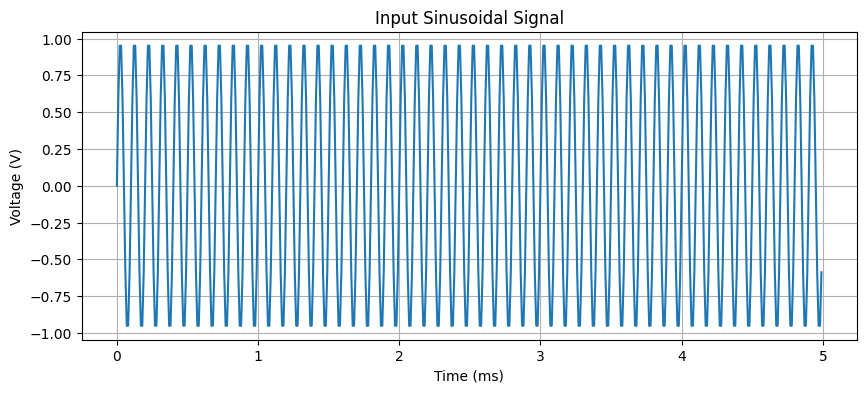

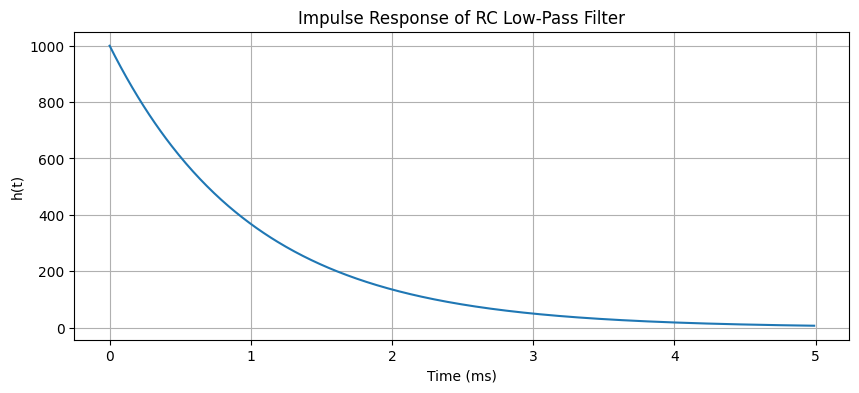

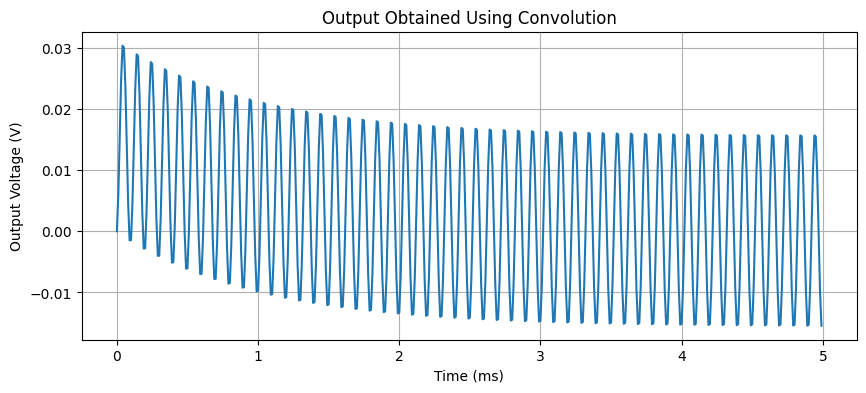

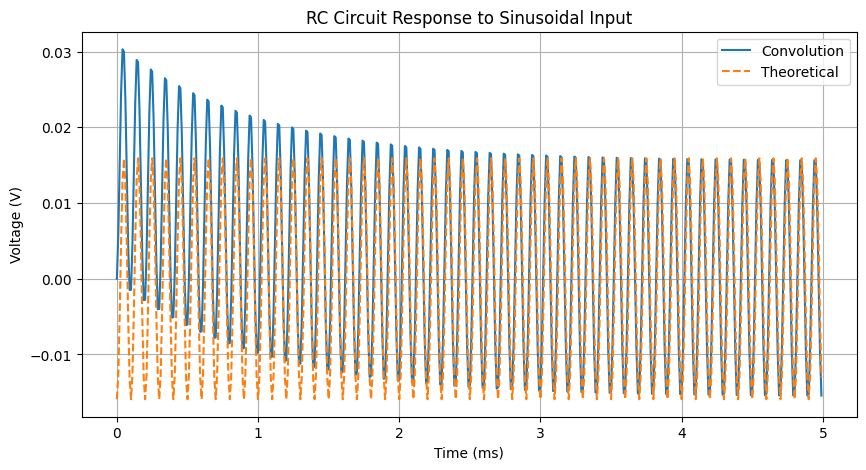

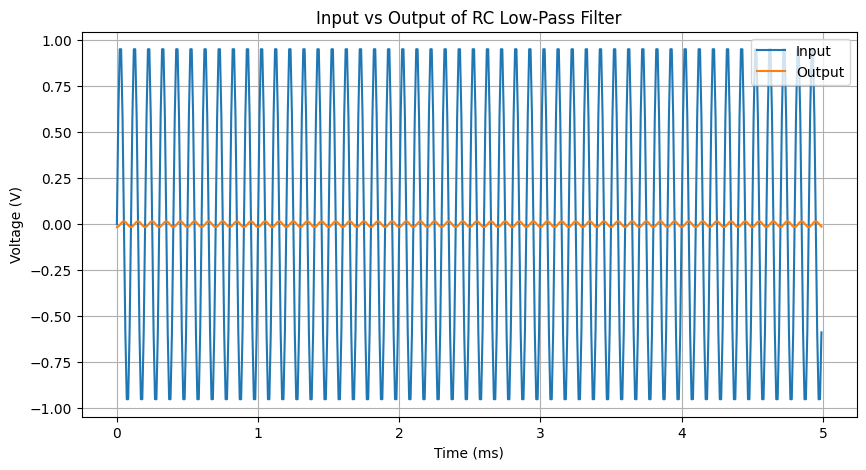

In [54]:
# 1. Circuit parameters
R = 1e3          # Resistance = 1 kOhm
C = 1e-6         # Capacitance = 1 uF

# Cutoff frequency
fc = 1 / (2 * np.pi * R * C)
wc = 1 / (R * C)

print(f"Cutoff frequency = {fc:.2f} Hz")
print(f"Cutoff angular frequency = {wc:.2f} rad/s")


# ============================================================
# 2. Input sinusoidal signal
# ============================================================

Vm = 1.0         # Input amplitude = 1 V
f = 10000         # Input frequency = 1 kHz
w = 2 * np.pi * f

Fs = 100000      # Sampling frequency = 100 kHz
Ts = 1 / Fs

t = np.arange(0, 5e-3, Ts)

x = Vm * np.sin(w * t)


# ============================================================
# 3. RC impulse response
# ============================================================

h = (1 / (R * C)) * np.exp(-t / (R * C))


# ============================================================
# 4. Convolution
# ============================================================

y_conv = convolve(x, h) * Ts

# Keep only the part corresponding to the original time vector
y_conv = y_conv[:len(t)]


# ============================================================
# 5. Theoretical frequency response
# ============================================================

H = 1 / (1 + 1j * w * R * C)

magnitude = abs(H)
phase = np.angle(H)

y_theory = Vm * magnitude * np.sin(w * t + phase)


# ============================================================
# 6. Display results
# ============================================================

print("\nInput signal:")
print(f"Frequency = {f} Hz")
print(f"Amplitude = {Vm} V")

print("\nTheoretical RC response:")
print(f"Magnitude = {magnitude:.4f}")
print(f"Gain = {20*np.log10(magnitude):.2f} dB")
print(f"Phase = {np.degrees(phase):.2f} degrees")

print("\nOutput amplitude:")
print(f"{Vm * magnitude:.4f} V")


# ============================================================
# 7. Plot input signal
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(t * 1000, x)

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Input Sinusoidal Signal")
plt.grid()

plt.show()


# ============================================================
# 8. Plot impulse response
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(t * 1000, h)

plt.xlabel("Time (ms)")
plt.ylabel("h(t)")
plt.title("Impulse Response of RC Low-Pass Filter")
plt.grid()

plt.show()


# ============================================================
# 9. Plot convolution output
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(t * 1000, y_conv)

plt.xlabel("Time (ms)")
plt.ylabel("Output Voltage (V)")
plt.title("Output Obtained Using Convolution")
plt.grid()

plt.show()


# ============================================================
# 10. Compare convolution with theoretical response
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(t * 1000, y_conv, label="Convolution")
plt.plot(t * 1000, y_theory, '--', label="Theoretical")

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("RC Circuit Response to Sinusoidal Input")

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 11. Compare input and output
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(t * 1000, x, label="Input")
plt.plot(t * 1000, y_theory, label="Output")

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Input vs Output of RC Low-Pass Filter")

plt.legend()
plt.grid()

plt.show()

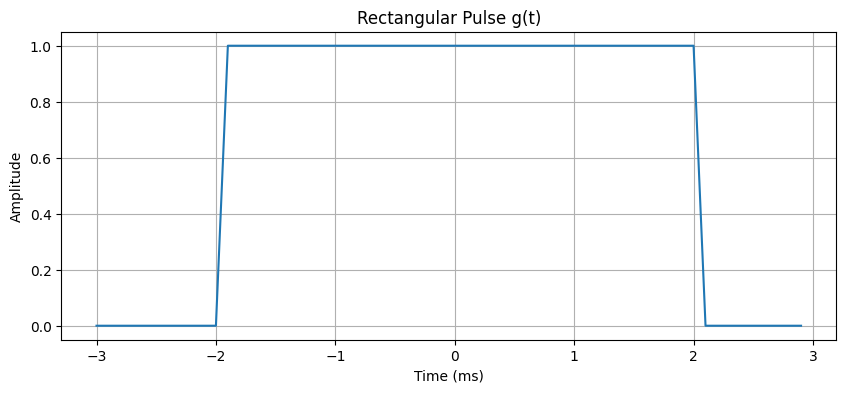

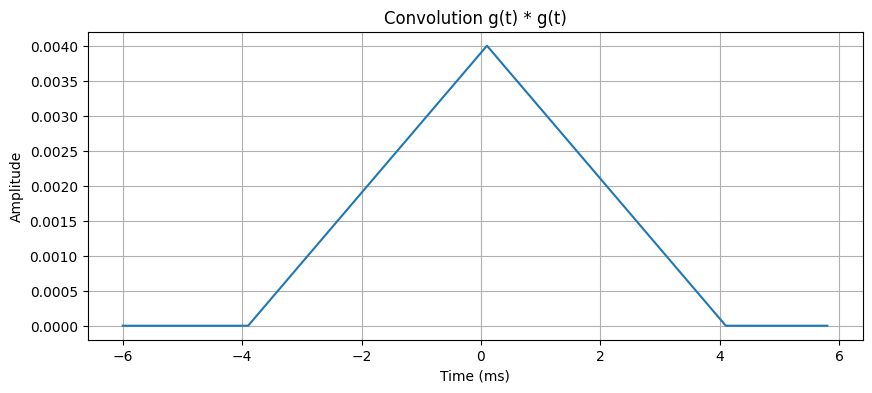

In [76]:
# Sampling parameters
Fs = 10000
Ts = 1 / Fs

# Time vector
t = np.arange(-3e-3, 3e-3, Ts)

# Rectangular pulse
g = np.where(np.abs(t) < 2e-3, 1, 0)

# ------------------------------------------------
# Convolution
# ------------------------------------------------
gg = convolve(g, g) * Ts

# Time axis for convolution
t_conv = np.arange(2 * t[0], 2 * t[-1] + Ts, Ts)

# ------------------------------------------------
# Plot original rectangular pulse
# ------------------------------------------------
plt.figure(figsize=(10, 4))

plt.plot(t * 1000, g)

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Rectangular Pulse g(t)")
plt.grid()
plt.show()

# ------------------------------------------------
# Plot convolution
# ------------------------------------------------
plt.figure(figsize=(10, 4))

plt.plot(t_conv * 1000, gg)

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Convolution g(t) * g(t)")
plt.grid()
plt.show()